In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
IMAGES_DIR = os.path.join(BASE_DIR, "report", "images")

os.makedirs(IMAGES_DIR, exist_ok=True)

In [54]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("items:", items.shape)
print("payments:", payments.shape)
print("products:", products.shape)
print("sellers:", sellers.shape)
print("translation:", translation.shape)

customers: (99441, 5)
orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
products: (32951, 9)
sellers: (3095, 4)
translation: (71, 2)


In [55]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(items, on="order_id", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(translation, on="product_category_name", how="left")

print("Размер после объединения:", df.shape)
df.head()

Размер после объединения: (118434, 34)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto


In [56]:
print("Размер датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество колонок:", df.shape[1])

Размер датасета: (118434, 34)
Количество строк: 118434
Количество колонок: 34


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  str    
 1   customer_id                    118434 non-null  str    
 2   order_status                   118434 non-null  str    
 3   order_purchase_timestamp       118434 non-null  str    
 4   order_approved_at              118258 non-null  str    
 5   order_delivered_carrier_date   116360 non-null  str    
 6   order_delivered_customer_date  115037 non-null  str    
 7   order_estimated_delivery_date  118434 non-null  str    
 8   customer_unique_id             118434 non-null  str    
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  str    
 11  customer_state                 118434 non-null  str    
 12  order_item_id                  117604 non

In [58]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
count,118434.000000,117604.000000,117604.000000,117604.000000,118431.000000,118431.000000,118431.000000,115906.000000,115906.000000,115906.000000,117584.000000,117584.000000,117584.00000,117584.000000,117604.000000
mean,35034.264392,1.195920,120.822849,20.045551,1.094207,2.937398,172.849395,48.767208,786.957302,2.207849,2114.281067,30.256872,16.63029,23.068394,24442.886483
std,29819.290218,0.697721,184.477367,15.861351,0.728290,2.774164,268.259831,10.035162,653.029009,1.719519,3788.754048,16.190874,13.45878,11.748372,27573.802989
min,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.00000,6.000000,1001.000000
25%,11310.000000,1.000000,39.900000,13.080000,1.000000,1.000000,60.860000,42.000000,347.000000,1.000000,300.000000,18.000000,8.00000,15.000000,6429.000000
50%,24240.000000,1.000000,74.900000,16.290000,1.000000,2.000000,108.200000,52.000000,601.000000,1.000000,700.000000,25.000000,13.00000,20.000000,13660.000000
75%,58464.500000,1.000000,134.900000,21.190000,1.000000,4.000000,189.245000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.00000,30.000000,28035.000000
max,99990.000000,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.00000,118.000000,99730.000000


In [59]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

order_delivered_customer_date    3397
product_category_name_english    2553
product_description_lenght       2528
product_category_name            2528
product_photos_qty               2528
product_name_lenght              2528
order_delivered_carrier_date     2074
product_weight_g                  850
product_height_cm                 850
product_length_cm                 850
product_width_cm                  850
seller_zip_code_prefix            830
product_id                        830
freight_value                     830
seller_id                         830
shipping_limit_date               830
order_item_id                     830
price                             830
seller_city                       830
seller_state                      830
order_approved_at                 176
payment_sequential                  3
payment_value                       3
payment_type                        3
payment_installments                3
dtype: int64

In [60]:
print("Количество дубликатов:", df.duplicated().sum())
df = df.drop_duplicates()
print("Размер после удаления дубликатов:", df.shape)

Количество дубликатов: 0
Размер после удаления дубликатов: (118434, 34)


In [61]:
TARGET = "payment_value"

print("Целевая переменная:", TARGET)
print("Тип задачи: регрессия")

Целевая переменная: payment_value
Тип задачи: регрессия


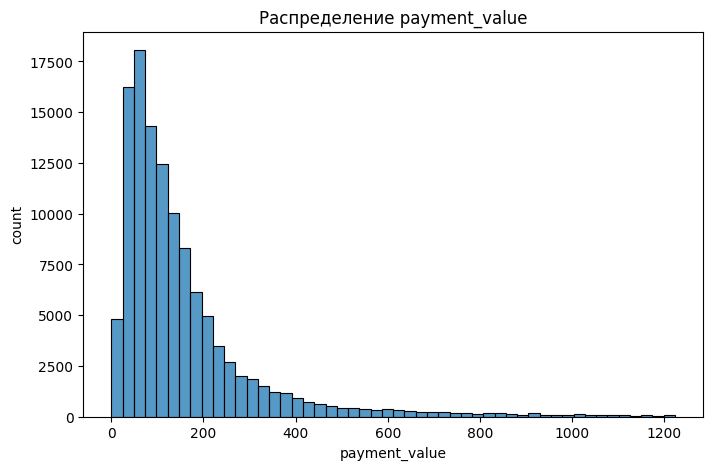

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(df["payment_value"], bins=50)

plt.title("Распределение payment_value")
plt.xlabel("payment_value")
plt.ylabel("count")

plt.savefig(os.path.join(IMAGES_DIR, "payment_distribution.png"))
plt.show()

In [63]:
df[TARGET].describe()

count    118431.000000
mean        172.849395
std         268.259831
min           0.000000
25%          60.860000
50%         108.200000
75%         189.245000
max       13664.080000
Name: payment_value, dtype: float64

In [64]:
q99 = df[TARGET].quantile(0.99)

print("99-й перцентиль:", q99)
print("Размер до удаления выбросов:", df.shape)

df = df[df[TARGET] <= q99].copy()

print("Размер после удаления выбросов:", df.shape)

99-й перцентиль: 1223.7
Размер до удаления выбросов: (118434, 34)
Размер после удаления выбросов: (117250, 34)


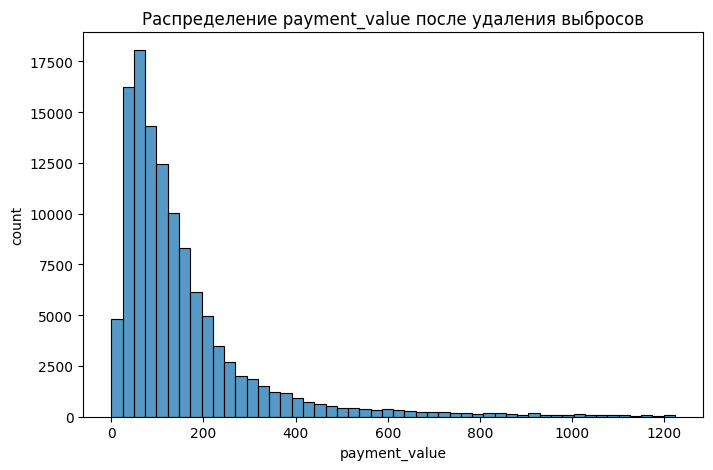

In [80]:
plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET], bins=50)
plt.title("Распределение payment_value после удаления выбросов")
plt.xlabel("payment_value")
plt.ylabel("count")

plt.savefig(os.path.join(IMAGES_DIR, "payment_distribution_clean.png"))
plt.show()

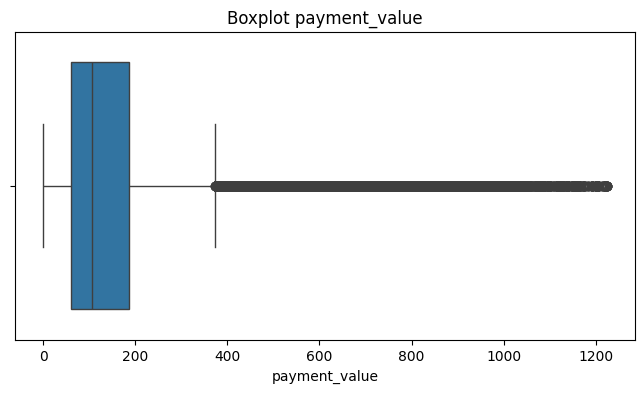

In [84]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["payment_value"])
plt.title("Boxplot payment_value")
plt.xlabel("payment_value")

plt.savefig(os.path.join(IMAGES_DIR, "boxplot.png"))
plt.show()


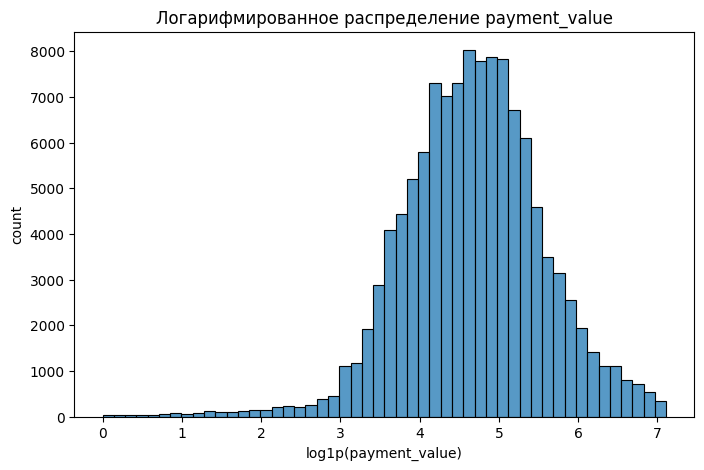

In [86]:
df["payment_value_log"] = np.log1p(df[TARGET])

plt.figure(figsize=(8, 5))
sns.histplot(df["payment_value_log"], bins=50)
plt.title("Логарифмированное распределение payment_value")
plt.xlabel("log1p(payment_value)")
plt.ylabel("count")

plt.savefig(os.path.join(IMAGES_DIR, "payment_log_distribution.png"))
plt.show()

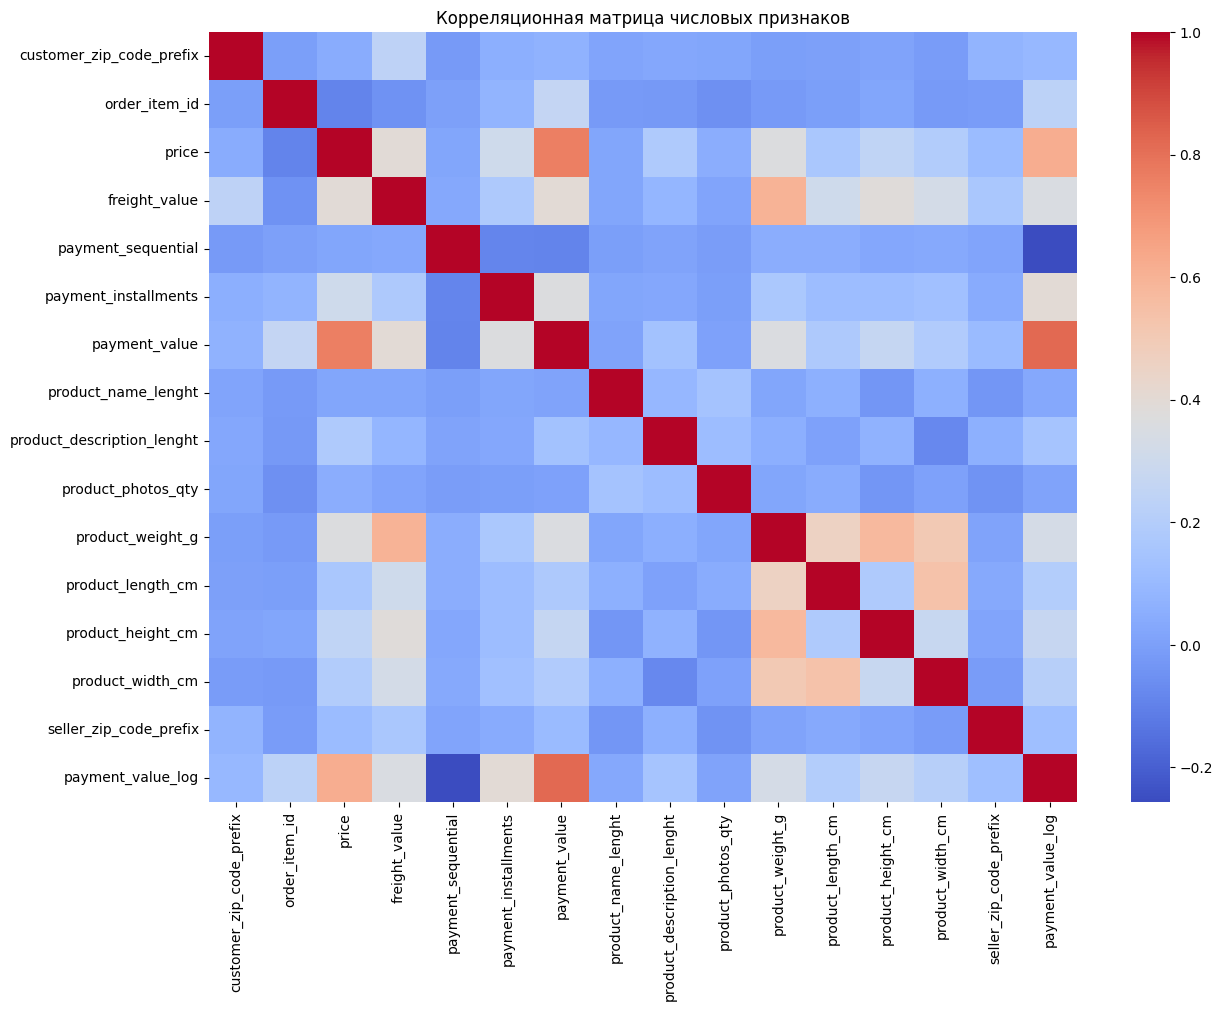

In [85]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Корреляционная матрица числовых признаков")

plt.savefig(os.path.join(IMAGES_DIR, "correlation.png"))
plt.show()

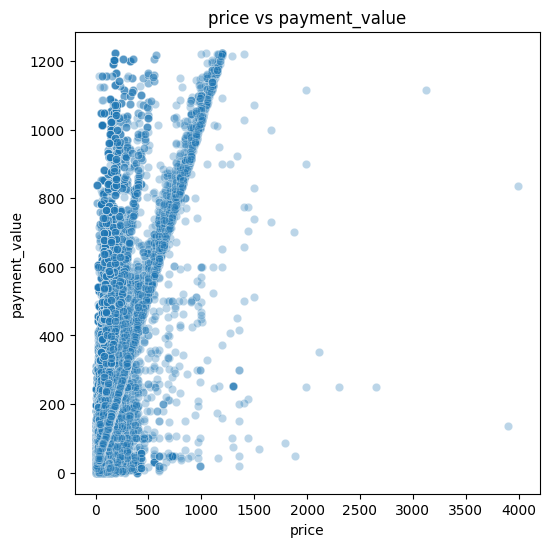

In [87]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=df["price"], y=df["payment_value"], alpha=0.3)
plt.title("price vs payment_value")
plt.xlabel("price")
plt.ylabel("payment_value")

plt.savefig(os.path.join(IMAGES_DIR, "price_vs_payment.png"))
plt.show()

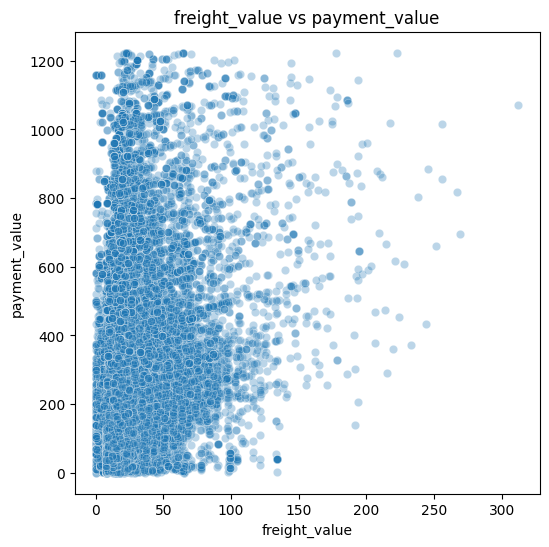

In [88]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=df["freight_value"], y=df["payment_value"], alpha=0.3)
plt.title("freight_value vs payment_value")
plt.xlabel("freight_value")
plt.ylabel("payment_value")

plt.savefig(os.path.join(IMAGES_DIR, "freight_vs_payment.png"))
plt.show()

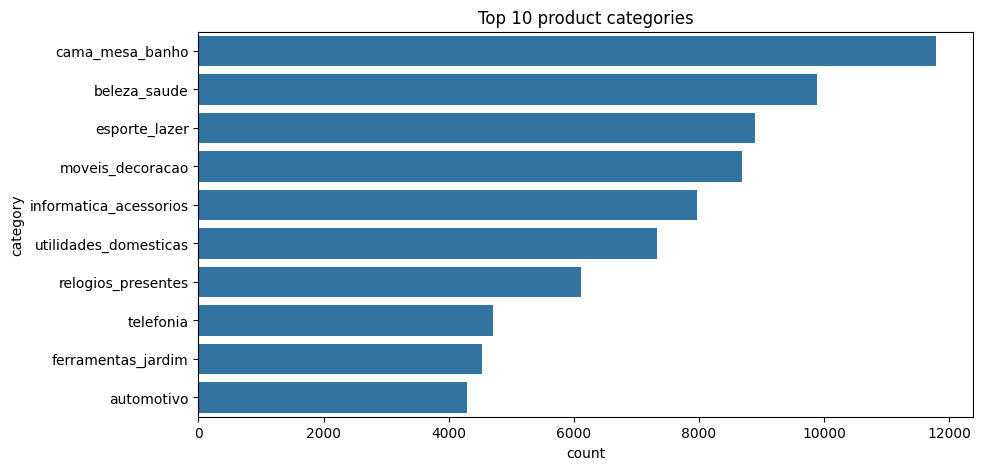

In [89]:
if "product_category_name" in df.columns:
    top_cat = df["product_category_name"].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_cat.values, y=top_cat.index)
    plt.title("Top 10 product categories")
    plt.xlabel("count")
    plt.ylabel("category")

    plt.savefig(os.path.join(IMAGES_DIR, "top_categories.png"))
    plt.show()

In [72]:
corr_with_target = numeric_df.corr()[TARGET].sort_values(ascending=False)
corr_with_target

payment_value                 1.000000
payment_value_log             0.821992
price                         0.762867
freight_value                 0.396869
payment_installments          0.365173
product_weight_g              0.358397
product_height_cm             0.266609
order_item_id                 0.261950
product_width_cm              0.185536
product_length_cm             0.179640
product_description_lenght    0.139643
seller_zip_code_prefix        0.103063
customer_zip_code_prefix      0.071492
product_name_lenght           0.012478
product_photos_qty            0.007587
payment_sequential           -0.094218
Name: payment_value, dtype: float64

In [73]:
final_df = df.select_dtypes(include=["number"]).copy()

final_df = final_df.drop(columns=["payment_value_log"], errors="ignore")
final_df = final_df.dropna()

print("Финальный датасет для обучения:", final_df.shape)
final_df.head()

Финальный датасет для обучения: (114762, 15)


,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix
0,3149,1.0,29.99,8.72,1.0,1.0,18.12,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0
1,3149,1.0,29.99,8.72,3.0,1.0,2.00,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0
2,3149,1.0,29.99,8.72,2.0,1.0,18.59,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0
3,47813,1.0,118.70,22.76,1.0,1.0,141.46,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0
4,75265,1.0,159.90,19.22,1.0,3.0,179.12,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0


In [74]:
final_df.to_csv("../data/processed/final_dataset.csv", index=False)

print("Файл сохранён: ../data/processed/final_dataset.csv")

Файл сохранён: ../data/processed/final_dataset.csv


## Выводы по анализу данных

В ходе анализа были получены следующие результаты:

- После объединения таблиц был сформирован единый датасет размером ~118k строк.
- Целевая переменная `payment_value` имеет сильное смещение вправо.
- В данных присутствуют выбросы, которые были удалены (значения выше 99-го перцентиля).
- Логарифмирование позволило сделать распределение более близким к нормальному.
- Признак `price` имеет сильную зависимость с `payment_value`.
- Признак `freight_value` также влияет на стоимость заказа.
- Некоторые категории товаров встречаются значительно чаще других.

Таким образом, выбранные признаки являются релевантными для задачи регрессии.